# Práctica 04: Análisis de datos Exploratorio con Python y Jupiter Notebook en un DataSet de Productoss de Amazon Store

**Progrma de estudios:** Ingeniería en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analítica de Base de Datos para Negocios Digitales \
**Docente:** M.T.I Marco Ramírez Hernández \
**Periodo:** Mayo - Agosto 2026

### Unidad 2: Preparación de los Datos

**Nombre del Estudiante:** Andrea Peña Leal \
**Matrícula:** 230379 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 30px; border-radius: 15px; text-align: center; margin-bottom: 20px;">
<h1 style="color: white; font-size: 2.2em; margin: 0;"> 
    🛒Productos de Amazon Store - Análisis Exploratorio de Datos Completo & Aprendizaje Automático Predictivo 
    (ML)
</h1>
<p style="color: #FFD700; font-size: 1.1em; margin-top: 10px;">
    Predicción de Precisos - Análisis de Categorias - Ingenieria de Funcionalidades - Comparación de Modeles
</p>
</div>

## Tabla de contenido 
| # | Sección | Descripción |
|---|---|---|
| 1 | [Instalaciones & Carga de datos](#s1) | Librerías, carga de CSV, primeros comandos de estructura.|
| 2 | [Diccionario de Datos](#s2) | Explicación del contenido de columnas y calcular el % de datos faltantes.|
| 3 | [Limpieza de Datos](#s3) | Aplicación de métodos básicos de limpieza (eliminación duplicados, agrupación, datos nulos.|
| 4 | [Ingenieria de Caracteristicas (Feature Engineering) ](#s4) | Crear, transformar, seleccionar o mejorar variables (features) de un conjunto de datos.|
| 5 | [Análisis Univariado (Univariate Analysis)](#s5) | Aplicación de la técnica estadística que estudia una sola variable a la vez para comprender sus características, distribución y comportamiento.|
| 6 | [Análisis de Categorías (Category Analysis)](#s6) |Técnica que consiste en examinar variables categóricas para identificar la frecuencia, distribución y comportamiento de las diferentes categorías dentro de un conjunto de datos.|
| 7 | [Análisis de Disponibilidad (Availability Analysis)](#s7) |Examinar el estado de los productos dentro del catálogo para determinar cuáles están disponibles, agotados o tienen algún otro estado de inventario.|
| 8 | [Análisis de Correlación y Análisis Bivariado (Correlation & Bivariate Analysis)](#s8) |EstudiaR la relación entre dos variables para determinar si existe alguna asociación o dependencia entre ellas.

## 1. Instalaciones & Carga de Datos  🔧<a id='s1'></a>
<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color:#0066cc;">
<b>Dataset:</b> Amazon India Listas de Productos - 1,436 productos entre Libros, Kindle, Deportes & más<br>
<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y disponibilidad<br>
<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in
</div>

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

#ml -Machine Learning -Entretenimiento de modelos metricas para predicir en este caso precios
from sklearn.preprocessing import LabelEncoder, StandardScaler  

print(f'Pandas   : {pd.__version__}')
print(f'NumPy    : {np.__version__}')
print('¡Todas las librerías cargaron con éxito!')

Pandas   : 2.3.3
NumPy    : 2.3.5
¡Todas las librerías cargaron con éxito!


In [2]:
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')
print(f' Shape   : {df_raw.shape}')
print(f' Columns   : {df_raw.columns.tolist()}')
df_raw.head(3)

 Shape   : (1449, 17)
 Columns   : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2. Diccionario de Datos <a id='s2'></a>

In [3]:
# Column dictionary
col_info = {
    'rl'             : 'URL del Producto en Amazon.in',
    'asin'            : 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name'            : 'Nombre o Título del Producto',
    'overview'        : 'Breve Reseña del Prodcuto (mayoría vacío [])',
    'price'           : 'Precio como string (e.g. "1,600.00")',
    'currency'        : 'Código de Divisa (todas en INR)',
    'availability'    : 'Texto del Status del Stock (Inventario)',
    'brand'           : 'Nombre de la Marca/Autor ',
    'about_item'      : 'Detalles/Especificaciones (mayoría faltante)',
    'img_source'      : 'URLs de Imágenes del Producto',
    'description'     : 'Descripción detalla y completa (mayoría faltante)',
    'specifications'  : 'Especificaciones Técnicas',
    'primary_category': 'Categoría Principal (Libros, Kindle, Deportes...)',
    'category_1'      : 'Subcategoría de nivel 1',
    'category_2'      : 'Subcategoría de nivel 2',
    'category_3'      : 'Subcategoría de nivel 3',
    'breadcrumbs'     : 'Ruta de Categorías',
}

print('Diccionario por columnas:')

for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() * 100
    print(
        f'{col:20s}  | '
        f'{desc[:45]:45s} | '
        f' Missing: {missing_pct:.0f}%'
        )
    

Diccionario por columnas:
rl                    | URL del Producto en Amazon.in                 |  Missing: 0%
asin                  | Número Estandarizado de Identificación por Am |  Missing: 0%
name                  | Nombre o Título del Producto                  |  Missing: 0%
overview              | Breve Reseña del Prodcuto (mayoría vacío [])  |  Missing: 0%
price                 | Precio como string (e.g. "1,600.00")          |  Missing: 24%
currency              | Código de Divisa (todas en INR)               |  Missing: 24%
availability          | Texto del Status del Stock (Inventario)       |  Missing: 33%
brand                 | Nombre de la Marca/Autor                      |  Missing: 1%
about_item            | Detalles/Especificaciones (mayoría faltante)  |  Missing: 92%
img_source            | URLs de Imágenes del Producto                 |  Missing: 1%
description           | Descripción detalla y completa (mayoría falta |  Missing: 92%
specifications        | Especifica

## 3. Limpieza de Datos <a id='s3'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pasos clave para la limpieza:</b><br>
• Parseas el precio strings como "1,600.00" -> float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [4]:
# =====================================================================
# SECTION 3- Data Cleaning
# =====================================================================
df = df_raw.copy()

# ---------------------------------------------------------------------
# —- Parse price —-
# ---------------------------------------------------------------------
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)


# ---------------------------------------------------------------------
# —- Standardise availability —-
# ---------------------------------------------------------------------
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:               return 'In Stock'
    if 'unavailable' in a:           return 'Unavailable'
    if '1 to 3' in a:                 return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a:   return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)


# ---------------------------------------------------------------------
# —- Text length features —-
# ---------------------------------------------------------------------
df['name_length'] = df['name'].fillna('').str.len()
df['name_words']  = df['name'].fillna('').str.split().str.len()
df['has_brand']   = df['brand'].notna().astype(int)
df['has_desc']    = df['description'].notna().astype(int)
df['has_specs']   = df['specifications'].notna().astype(int)


# ---------------------------------------------------------------------
# —- Duplicate check —-
# ---------------------------------------------------------------------
dupes = df.duplicated(subset='asin').sum()

print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')

# Mostrar las primeras 5 filas con columnas seleccionadas
df[['name', 'price_clean', 'avail_clean', 'primary_category', 'name_length']].head(5)

✅ Price parsed: 1,100 / 1,449 products
✅ Duplicate ASINs: 11
✅ Availability categories: {'In Stock': 609, 'Unknown': 482, 'Ships 1-3 weeks': 122, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 80, 'Other': 25, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


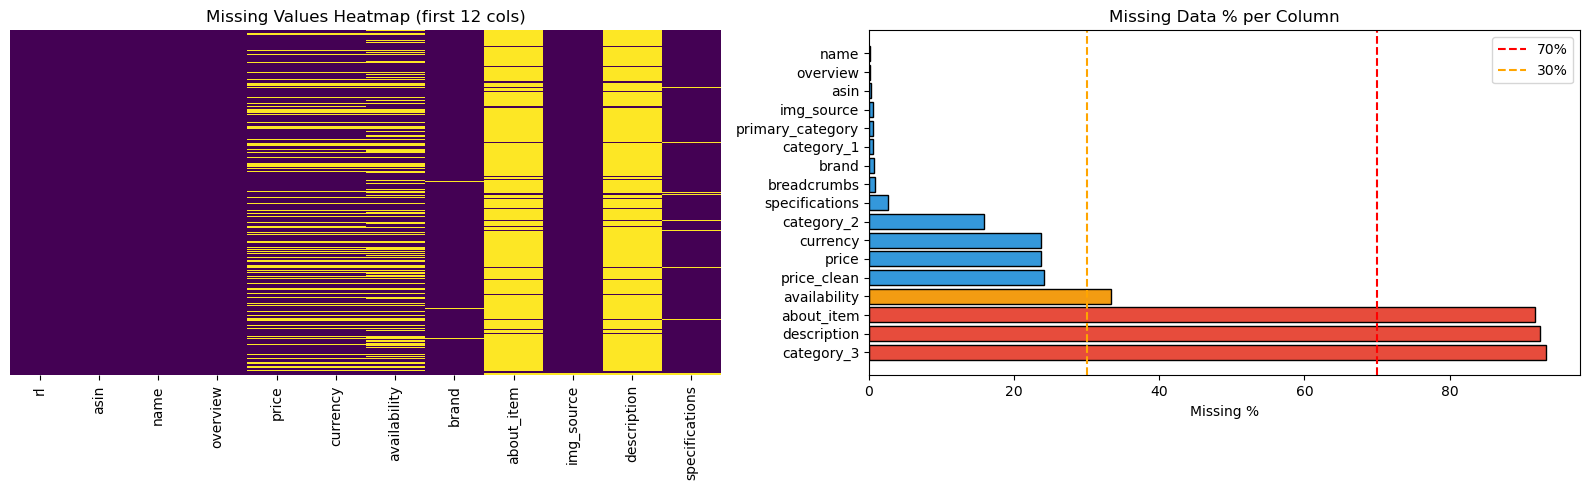

                  Missing Count  Missing Pct
category_3                 1352         93.3
description                1340         92.5
about_item                 1329         91.7
availability                482         33.3
price_clean                 349         24.1
price                       344         23.7
currency                    344         23.7
category_2                  230         15.9
specifications               38          2.6
breadcrumbs                  12          0.8
brand                        10          0.7
category_1                    9          0.6
primary_category              9          0.6
img_source                    9          0.6
asin                          4          0.3
overview                      3          0.2
name                          1          0.1


In [5]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct'  : (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(df[df.columns[:12]].isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap (first 12 cols)')

mv = missing[missing['Missing Pct'] > 0]
colors_mv = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
             for v in mv['Missing Pct']]
axes[1].barh(mv.index, mv['Missing Pct'], color=colors_mv, edgecolor='black')
axes[1].axvline(70, color='red', linestyle='--', label='70%')
axes[1].axvline(30, color='orange', linestyle='--', label='30%')
axes[1].set_xlabel('Missing %'); axes[1].set_title('Missing Data % per Column')
axes[1].legend()

plt.tight_layout(); plt.show()
print(missing[missing['Missing Count'] > 0].to_string())



## 4. Ingenieria de Caracteristicas (Feature Engineering) <a id='s3'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>Ejemplo Cotidiano:</b> Un agente inmobiliario no solo utiliza los metros cuadrados brutos, sino que también considera la ubicación, la antigüedad y
el estado. Nosotros hacemos lo mismo: extraemos información más valiosa del texto sin procesar y las categorías..
</div>

In [6]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total features engineered: {len(df.columns)}')
print('\nPrice tier distribution:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)

✅ Total features engineered: 39

Price tier distribution:
price_tier
1_budget     104
2_low        288
3_mid        319
4_premium    262
5_luxury     127
Unknown      349


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5. Análisis Univariado (Univariate Analysis) 📊 <a id='s5'></a>

<div style="background:#eaf4ff; padding:12px; border-left:4px solid #0066cc; border-radius:5px; color:#0066cc;">
<b>Pregunta clave:</b> ¿Cómo es la distribución de los precios? ¿Existen valores atípicos (outliers)? ¿Los datos presentan asimetría (sesgo)?.
</div>

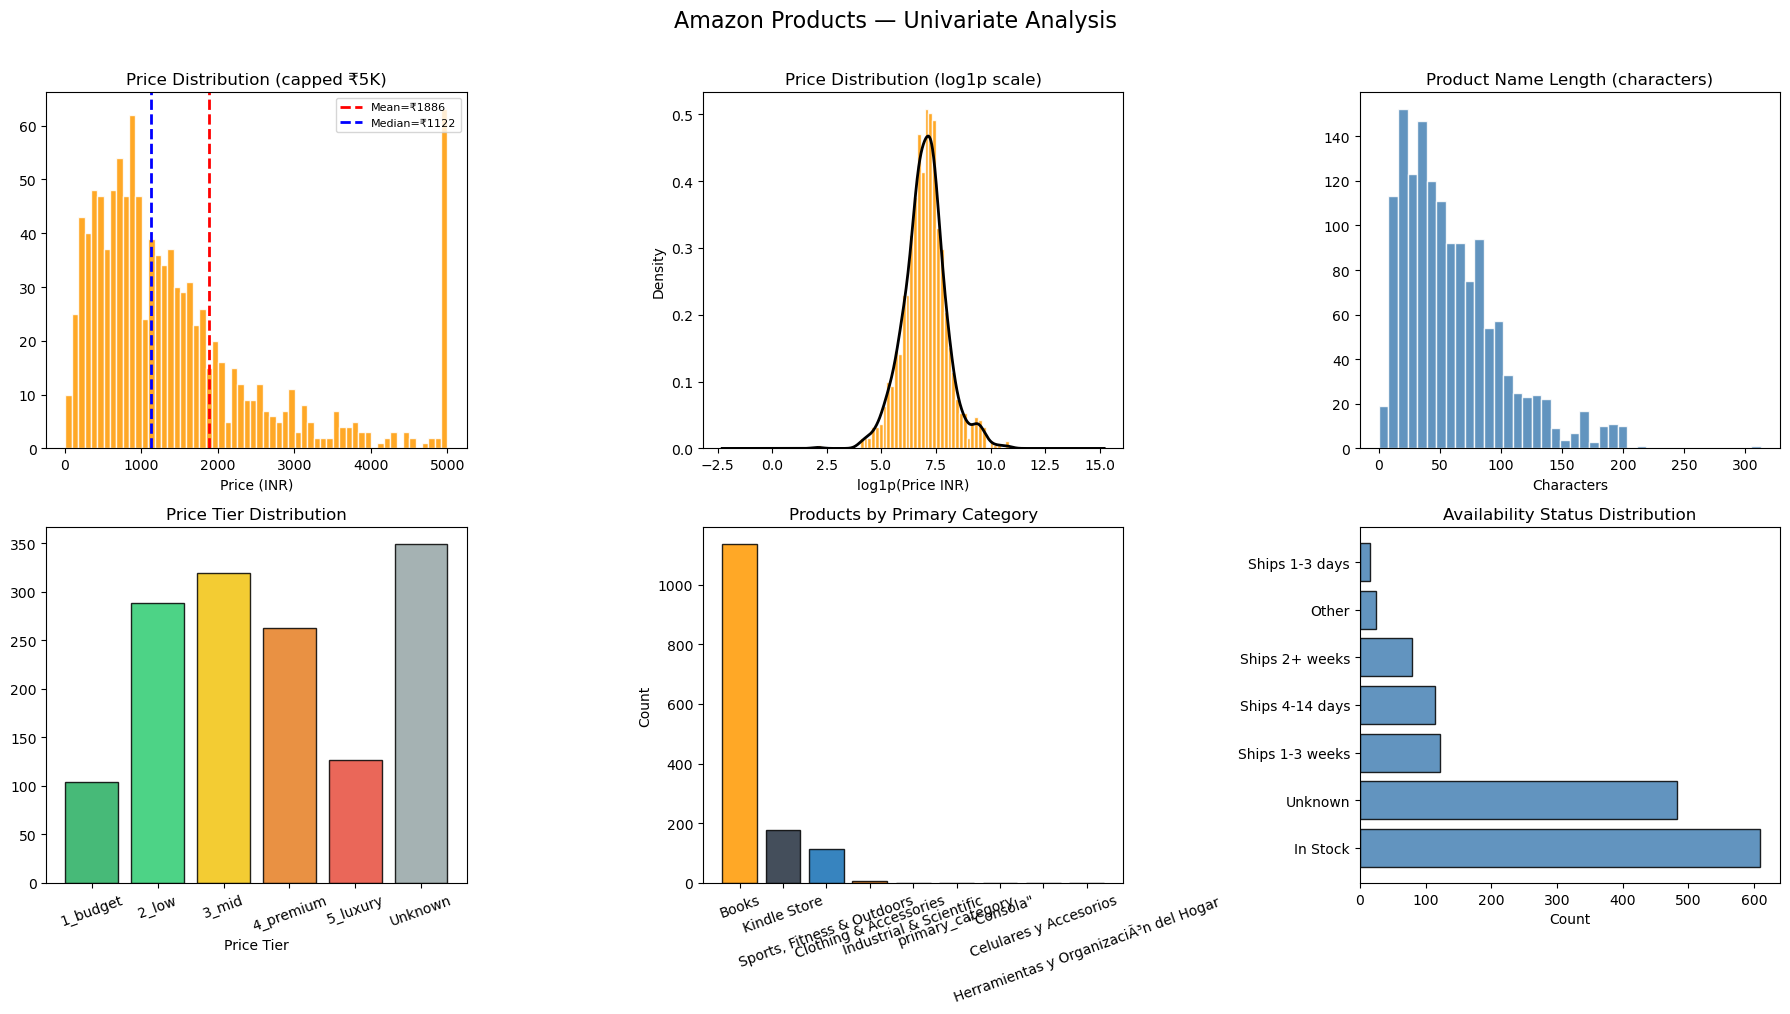

NameError: name 'shapiro' is not defined

In [15]:
# ============================================================
# 📊 Sección 4 — Análisis Univariado
# ============================================================

# Filtrar únicamente productos con precio válido y mayor a cero
df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

# Crear una figura con 2 filas y 3 columnas de gráficos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ============================================================
# Distribución de precios originales
# ============================================================

# Histograma de precios limitando valores máximos a ₹5000
# para evitar que los outliers distorsionen la visualización
axes[0,0].hist(
    df_priced['price_clean'].clip(upper=5000),
    bins=60,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85
)

# Línea vertical para la media
axes[0,0].axvline(
    df_priced['price_clean'].mean(),
    color='red',
    linestyle='--',
    lw=2,
    label=f'Mean=₹{df_priced["price_clean"].mean():.0f}'
)

# Línea vertical para la mediana
axes[0,0].axvline(
    df_priced['price_clean'].median(),
    color='blue',
    linestyle='--',
    lw=2,
    label=f'Median=₹{df_priced["price_clean"].median():.0f}'
)

# Configuración del gráfico
axes[0,0].set_title('Price Distribution (capped ₹5K)')
axes[0,0].set_xlabel('Price (INR)')
axes[0,0].legend(fontsize=8)

# ============================================================
# Distribución de precios transformados con logaritmo
# ============================================================

# Histograma de precios transformados usando log1p
axes[0,1].hist(
    df_priced['log_price'],
    bins=50,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85,
    density=True
)

# Curva de densidad (KDE)
df_priced['log_price'].plot.kde(
    ax=axes[0,1],
    color='black',
    lw=2
)

# Configuración del gráfico
axes[0,1].set_title('Price Distribution (log1p scale)')
axes[0,1].set_xlabel('log1p(Price INR)')

# ============================================================
# Longitud del nombre de los productos
# ============================================================

# Histograma de la cantidad de caracteres en los nombres
axes[0,2].hist(
    df['name_length'],
    bins=40,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)

# Configuración del gráfico
axes[0,2].set_title('Product Name Length (characters)')
axes[0,2].set_xlabel('Characters')

# ============================================================
# Distribución por rango de precios (Price Tier)
# ============================================================

# Contar productos por nivel de precio
tier_counts = df['price_tier'].value_counts().sort_index()

# Colores para cada nivel
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']

# Crear gráfico de barras
axes[1,0].bar(
    tier_counts.index,
    tier_counts.values,
    color=tier_colors[:len(tier_counts)],
    edgecolor='black',
    alpha=0.85
)

# Configuración del gráfico
axes[1,0].set_title('Price Tier Distribution')
axes[1,0].set_xlabel('Price Tier')
axes[1,0].tick_params(axis='x', rotation=20)

# ============================================================
# Productos por categoría principal
# ============================================================

# Contar productos por categoría
cat_counts = df['primary_category'].value_counts()

# Crear gráfico de barras
axes[1,1].bar(
    cat_counts.index,
    cat_counts.values,
    color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
    edgecolor='black',
    alpha=0.85
)

# Configuración del gráfico
axes[1,1].set_title('Products by Primary Category')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=20)

# ============================================================
# Distribución del estado de disponibilidad
# ============================================================

# Contar productos según su disponibilidad
avail_counts = df['avail_clean'].value_counts()

# Crear gráfico de barras horizontales
axes[1,2].barh(
    avail_counts.index,
    avail_counts.values,
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)

# Configuración del gráfico
axes[1,2].set_title('Availability Status Distribution')
axes[1,2].set_xlabel('Count')

# ============================================================
# Mostrar todos los gráficos
# ============================================================

# Título general de la figura
plt.suptitle('Amazon Products — Univariate Analysis', fontsize=16, y=1.01)

# Ajustar espacios automáticamente
plt.tight_layout()

# Mostrar figura
plt.show()

# ============================================================
# Prueba de normalidad Shapiro-Wilk
# ============================================================

# Tomar una muestra de hasta 500 registros para evaluar normalidad
stat, p = shapiro(
    df_priced['log_price'].sample(
        min(500, len(df_priced)),
        random_state=42
    )
)

# Mostrar resultado de la prueba
print(f'Shapiro-Wilk (log price, n=500): stat={stat:.4f}, p={p:.6f}')

# Interpretación automática
print(
    f'Price is {"normally distributed after log transform" if p > 0.05 else "still non-normal after log transform"}'
)

# ============================================================
# Estadísticas descriptivas de los precios
# ============================================================

print(f'\nPrice stats (INR):')

# Mostrar resumen estadístico
print(
    df_priced['price_clean']
    .describe()
    .round(2)
    .to_string()
)

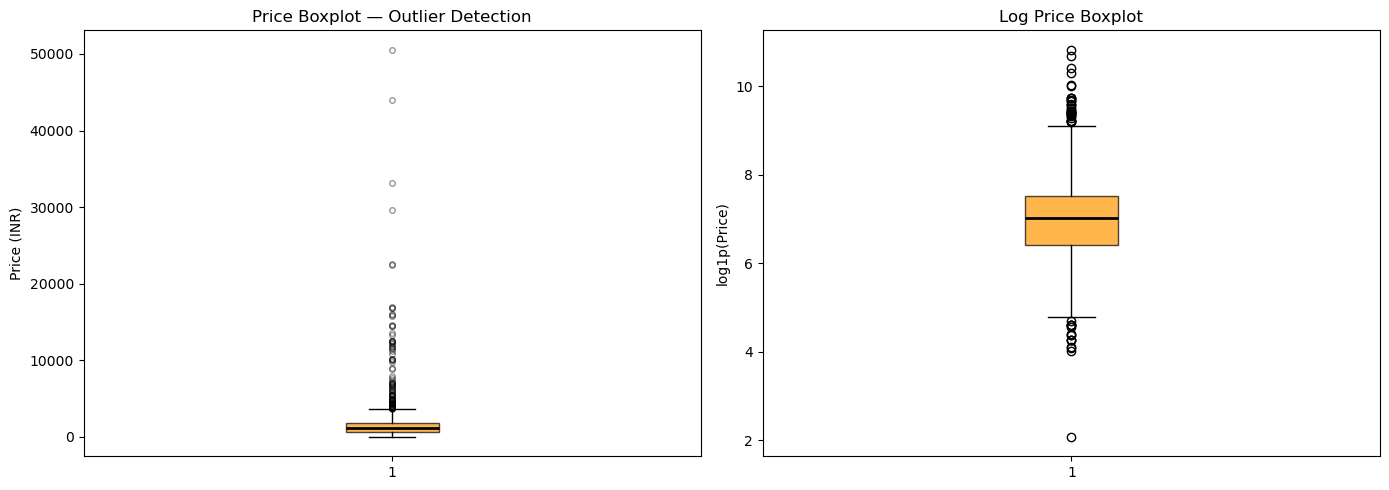

IQR method outliers: 94 (8.6%)
Price range (non-outlier): ₹-1242 – ₹3705

Top 10 most expensive products:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)     29633.00                 

In [14]:
# 📦 Análisis de Valores Atípicos (Outlier Analysis) usando Boxplot e IQR

# Crear una figura con 2 gráficos (1 fila y 2 columnas)
# figsize define el tamaño total de la figura
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ==========================
# Boxplot de precios originales
# ==========================

# Generar diagrama de caja para la columna 'price_clean'
axes[0].boxplot(
    df_priced['price_clean'],
    patch_artist=True,  # Permite colorear la caja
    boxprops=dict(facecolor='#FF9900', alpha=0.7),  # Color de la caja
    medianprops=dict(color='black', lw=2),          # Línea de la mediana
    flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red')  # Valores atípicos
)

# Título del gráfico
axes[0].set_title('Price Boxplot — Outlier Detection')

# Etiqueta del eje Y
axes[0].set_ylabel('Price (INR)')

# ==========================
# Boxplot de precios transformados con logaritmo
# ==========================

# Generar diagrama de caja para la columna 'log_price'
axes[1].boxplot(
    df_priced['log_price'],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)

# Título del gráfico
axes[1].set_title('Log Price Boxplot')

# Etiqueta del eje Y
axes[1].set_ylabel('log1p(Price)')

# Ajustar automáticamente el espacio entre gráficos
plt.tight_layout()

# Mostrar los gráficos
plt.show()

# ==========================
# Cálculo del método IQR
# ==========================

# Obtener el primer cuartil (Q1) y el tercer cuartil (Q3)
Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])

# Calcular el Rango Intercuartílico (IQR)
IQR = Q3 - Q1

# Identificar valores atípicos utilizando la regla:
# Menor que Q1 - 1.5*IQR o mayor que Q3 + 1.5*IQR
outliers = df_priced[
    (df_priced['price_clean'] < Q1 - 1.5 * IQR) |
    (df_priced['price_clean'] > Q3 + 1.5 * IQR)
]

# ==========================
# Mostrar resultados
# ==========================

# Imprimir cantidad y porcentaje de valores atípicos encontrados
print(f'IQR method outliers: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')

# Mostrar el rango de precios considerado normal (sin outliers)
print(f'Price range (non-outlier): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')

# Mostrar encabezado
print(f'\nTop 10 most expensive products:')

# Mostrar los 10 productos más caros junto con su precio y categoría
print(
    df_priced.nlargest(10, 'price_clean')
    [['name', 'price_clean', 'primary_category']]
    .to_string(index=False)
)

## 6. Análisis de Categorías (Category Analysis)🗂️<a id='s6'></a>

<div style="background:#fff8dc; padding:12px; border-left:4px solid #f1c40f; border-radius:5px; color:#b8860b;">
<b>Pregunta clave:</b> ¿Qué categorías tienen los precios más altos? ¿Qué subcategorías predominan? ¿Dónde se encuentra el mayor valor?
</div>

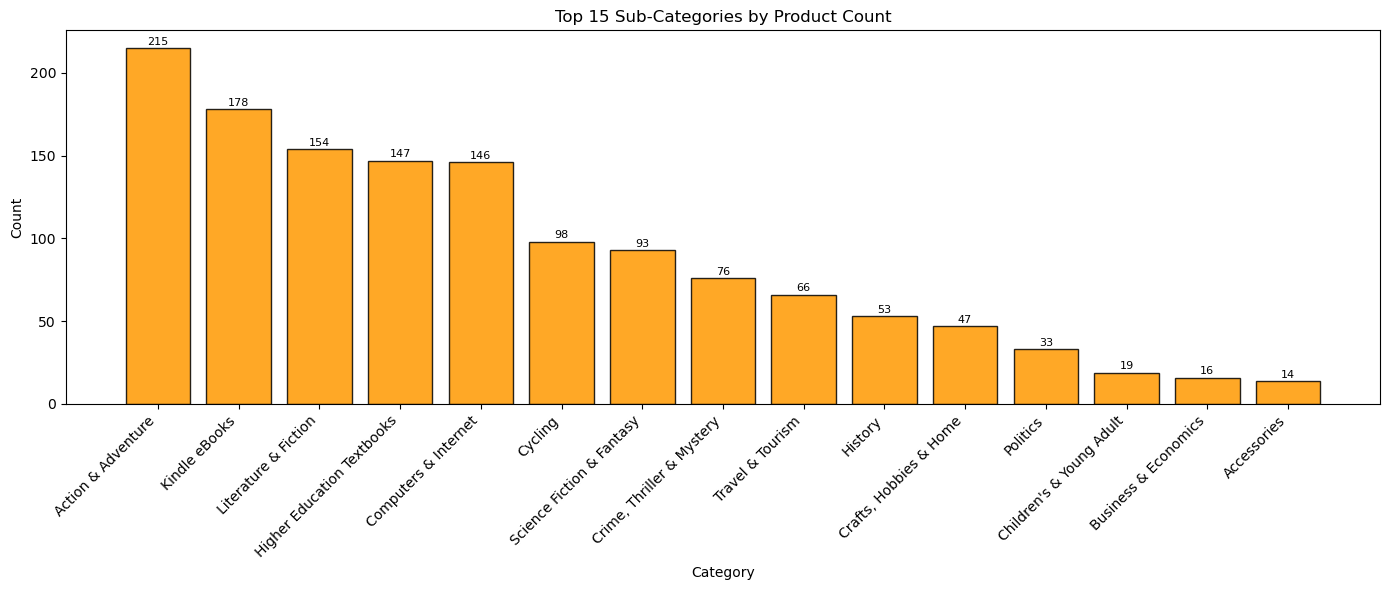

In [16]:
# ============================================================
# 🗂️ SECCIÓN 5 — Análisis de Categorías
# ============================================================
# Obtener las 15 subcategorías con mayor cantidad de productos
# value_counts() cuenta cuántas veces aparece cada categoría
# head(15) selecciona las 15 más frecuentes
top15_cat1 = df['category_1'].value_counts().head(15)
# Crear una figura para el gráfico
plt.figure(figsize=(14, 6))
# Generar gráfico de barras
bars = plt.bar(
    top15_cat1.index,      # Nombres de las subcategorías
    top15_cat1.values,     # Cantidad de productos por subcategoría
    color='#FF9900',       # Color de las barras
    edgecolor='black',     # Borde de las barras
    alpha=0.85             # Transparencia
)

# Agregar etiquetas con los valores encima de cada barra
for bar, val in zip(bars, top15_cat1.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # Posición horizontal
        bar.get_height() + 2,               # Posición vertical
        str(val),                           # Valor a mostrar
        ha='center',                        # Centrar texto
        fontsize=8
    )
# Configurar título del gráfico
plt.title('Top 15 Sub-Categories by Product Count')
# Etiqueta del eje X
plt.xlabel('Category')
# Etiqueta del eje Y
plt.ylabel('Count')
# Rotar etiquetas del eje X para mejorar la legibilidad
plt.xticks(rotation=45, ha='right')
# Ajustar automáticamente los márgenes y espacios
plt.tight_layout()
# Mostrar el gráfico
plt.show()

C:\Users\PC-25\AppData\Local\Temp\ipykernel_8824\3999129018.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


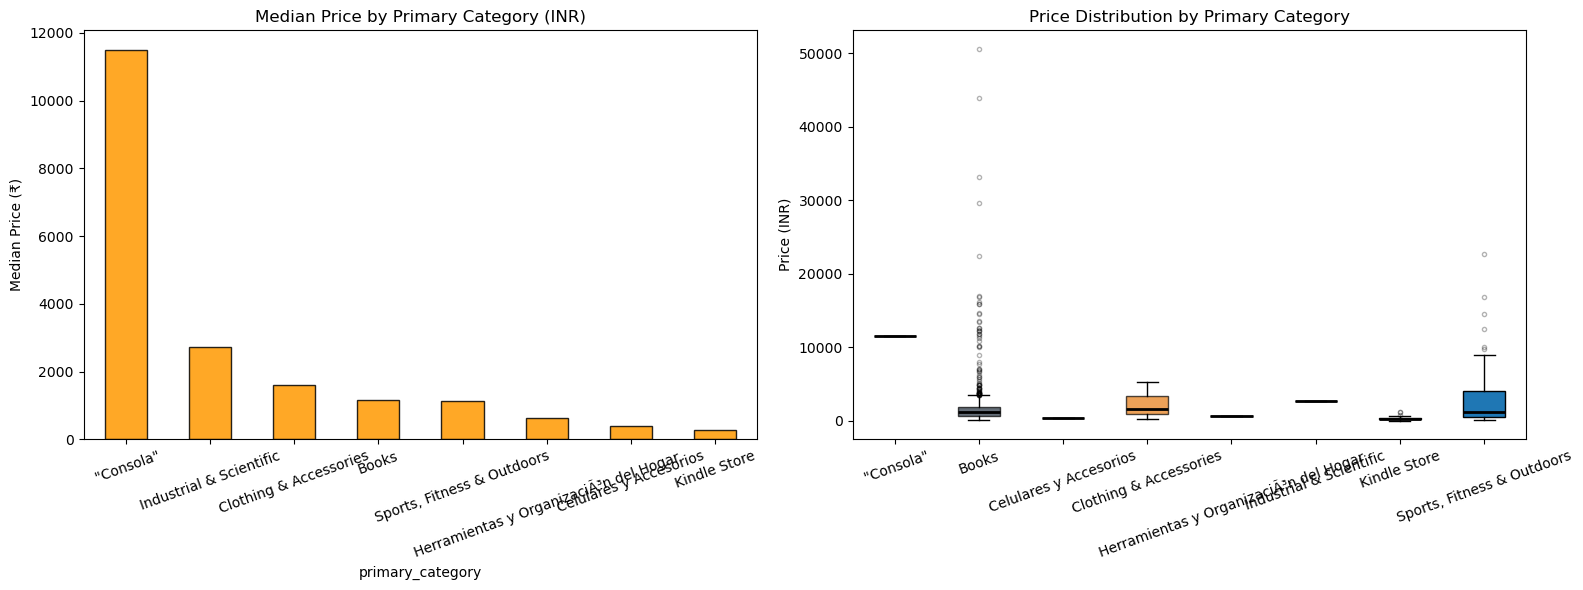

Price stats by primary category:
                                           mean   median  count
primary_category                                               
 "Consola"                              11499.0  11499.0      1
Books                                    1825.6   1145.0    955
Celulares y Accesorios                    399.0    399.0      1
Clothing & Accessories                   2249.2   1606.5      6
Herramientas y OrganizaciÃ³n del Hogar    622.5    622.5      1
Industrial & Scientific                  2738.0   2738.0      1
Kindle Store                              350.0    281.4     30
Sports, Fitness & Outdoors               2907.9   1125.0     93


In [17]:
# ============================================================
# 💰 Precio por Categoría Principal
# ============================================================
# Crear una figura con 2 gráficos (1 fila y 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# ============================================================
# Estadísticas de precios por categoría principal
# ============================================================
# Agrupar los datos por categoría principal y calcular:
# - Precio promedio (mean)
# - Precio mediano (median)
# - Cantidad de productos (count)
cat_price = (
    df_priced
    .groupby('primary_category')['price_clean']
    .agg(['mean', 'median', 'count'])
    .round(1)
)
# ============================================================
# Gráfico de barras: Precio mediano por categoría
# ============================================================
# Ordenar las categorías de mayor a menor según su precio mediano
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)
# Configuración del gráfico
axes[0].set_title('Median Price by Primary Category (INR)')
axes[0].set_ylabel('Median Price (₹)')
axes[0].tick_params(axis='x', rotation=20)
# ============================================================
# Boxplot: Distribución de precios por categoría
# ============================================================
# Crear una lista con los precios de cada categoría
cat_groups = [
    df_priced[df_priced['primary_category'] == c]['price_clean'].dropna()
    for c in cat_price.index
]

# Generar diagrama de caja para comparar la distribución
# de precios entre categorías
bp = axes[1].boxplot(
    cat_groups,
    labels=cat_price.index,
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)
# Colores asignados a cada categoría
colors_cat = ['#FF9900', '#232F3E', '#146EB4', '#E47911', '#999']
# Aplicar colores a las cajas del boxplot
for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
# Configuración del gráfico
axes[1].set_title('Price Distribution by Primary Category')
axes[1].set_ylabel('Price (INR)')
axes[1].tick_params(axis='x', rotation=20)
# ============================================================
# Mostrar gráficos
# ============================================================
# Ajustar automáticamente los espacios entre gráficos
plt.tight_layout()
# Mostrar figura
plt.show()
# ============================================================
# Mostrar estadísticas por categoría
# ============================================================
print('Price stats by primary category:')
# Imprimir tabla con media, mediana y cantidad de productos
print(cat_price.to_string())

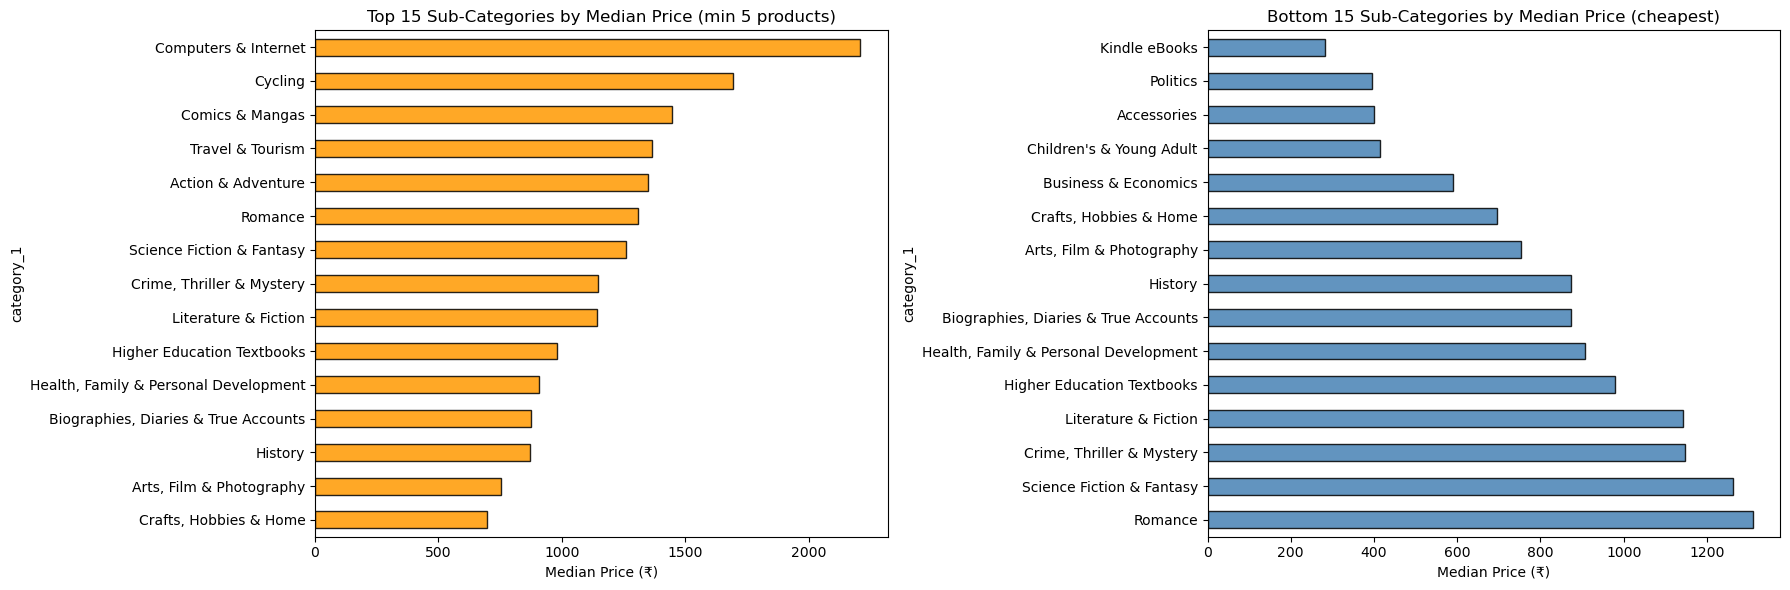

In [18]:
# ============================================================
# Top 15 y Bottom 15 Subcategorías por Precio Mediano
# ============================================================
# Agrupar los productos por subcategoría (category_1)
# y calcular:
# - Precio mediano (median)
# - Cantidad de productos (count)
# Se consideran únicamente subcategorías con al menos 5 productos
top_cat1_price = (
    df_priced
    .groupby('category_1')['price_clean']
    .agg(['median', 'count'])
    .query('count >= 5')
    .sort_values('median', ascending=False)
    .head(15)
)
# Crear una figura con 2 gráficos (1 fila y 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
# ============================================================
# Top 15 subcategorías más caras
# ============================================================
# Crear gráfico de barras horizontales con las subcategorías
# que tienen el precio mediano más alto
top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

# Configuración del gráfico
axes[0].set_title('Top 15 Sub-Categories by Median Price (min 5 products)')
axes[0].set_xlabel('Median Price (₹)')
# ============================================================
# Top 15 subcategorías más económicas
# ============================================================
# Obtener las subcategorías con menor precio mediano
# considerando únicamente aquellas con al menos 5 productos
bottom_cat1 = (
    df_priced
    .groupby('category_1')['price_clean']
    .agg(['median', 'count'])
    .query('count >= 5')
    .sort_values('median')
    .head(15)
)
# Crear gráfico de barras horizontales para las categorías más baratas
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1],
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)
# Configuración del gráfico
axes[1].set_title('Bottom 15 Sub-Categories by Median Price (cheapest)')
axes[1].set_xlabel('Median Price (₹)')
# ============================================================
# Mostrar gráficos
# ============================================================
# Ajustar automáticamente los espacios entre gráficos
plt.tight_layout()
# Mostrar figura
plt.show()

## 7.  Análisis de Disponibilidad (Availability Analysis)📦 <a id='s7'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#1e8449;">
<b>Pregunta clave:</b> ¿El estado de disponibilidad afecta el precio? ¿Es más probable que los productos premium estén agotados?
</div>

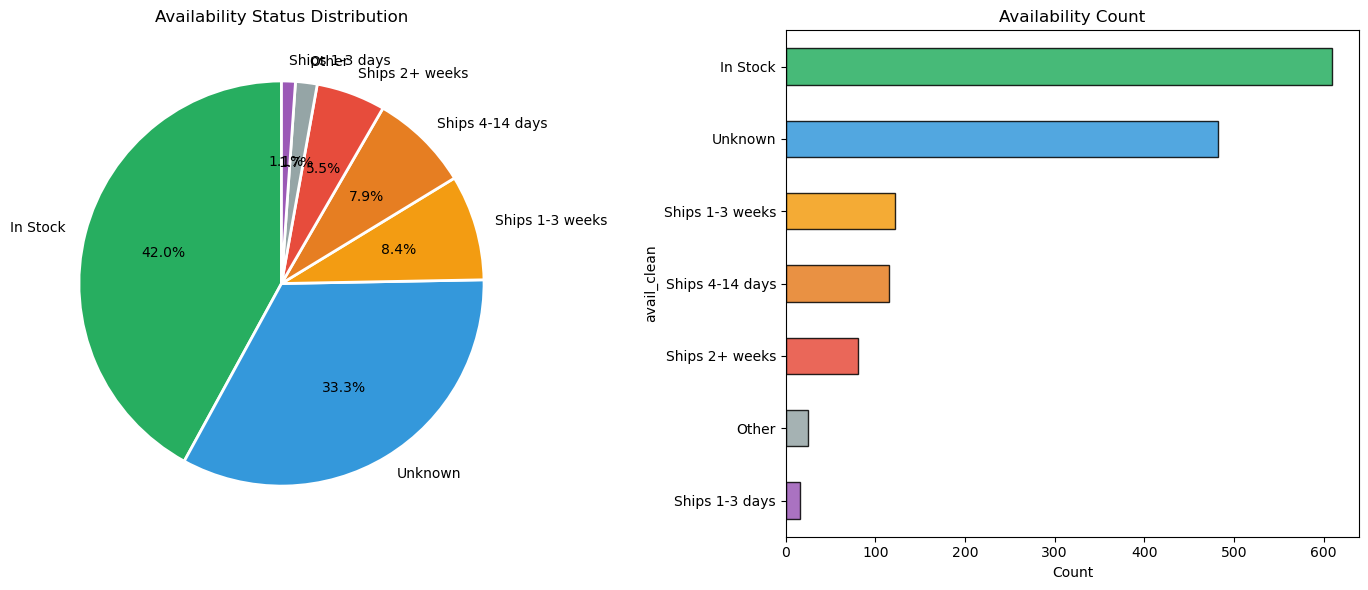

In [20]:
# ============================================================
# SECCIÓN 6 — Análisis de Disponibilidad
# ============================================================
# Contar cuántos productos existen en cada estado de disponibilidad
# (Disponible, Agotado, Stock limitado, etc.)
avail_counts = df['avail_clean'].value_counts()
# Definir una paleta de colores para los gráficos
avail_colors = [
    '#27ae60', '#3498db', '#f39c12', '#e67e22',
    '#e74c3c', '#95a5a6', '#9b59b6', '#1abc9c'
]
# Crear una figura con 2 gráficos (1 fila y 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# ============================================================
# Gráfico circular (Pie Chart)
# ============================================================
# Mostrar la proporción de productos por estado de disponibilidad
axes[0].pie(
    avail_counts.values,                    # Cantidad de productos
    labels=avail_counts.index,              # Etiquetas de cada categoría
    colors=avail_colors[:len(avail_counts)],# Colores asignados
    autopct='%1.1f%%',                      # Mostrar porcentaje
    startangle=90,                          # Iniciar desde arriba
    wedgeprops=dict(
        edgecolor='white',                  # Borde blanco
        linewidth=2
    )
)
# Título del gráfico
axes[0].set_title('Availability Status Distribution')
# ============================================================
# Gráfico de barras horizontales
# ============================================================
# Ordenar los estados de disponibilidad por cantidad
# y generar gráfico de barras horizontales
avail_counts.sort_values().plot.barh(
    ax=axes[1],
    color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black',
    alpha=0.85
)
# Configuración del gráfico
axes[1].set_title('Availability Count')
axes[1].set_xlabel('Count')
# ===========================================================
# Mostrar gráficos
# ============================================================
# Ajustar automátcamente los espacios
plt.tight_layout()
# Mostrar figura
plt.show()

C:\Users\PC-25\AppData\Local\Temp\ipykernel_8824\1988801065.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


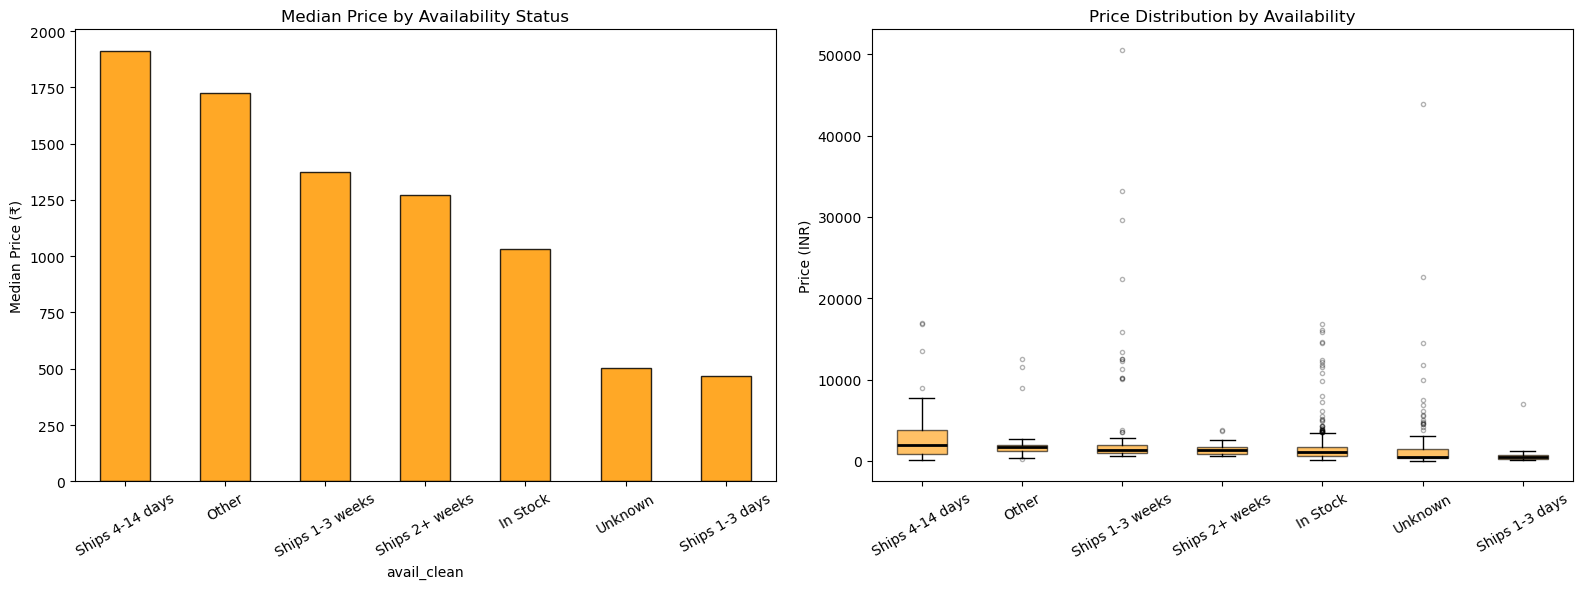

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1724.2  2644.9     24
Ships 1-3 weeks  1376.0  3210.8    122
Ships 2+ weeks   1273.0  1385.9     80
In Stock         1031.0  1493.4    601
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [21]:
# ============================================================
# Precio según el Estado de Disponibilidad
# ============================================================
# Agrupar los productos por estado de disponibilidad y calcular:
# - Precio mediano (median)
# - Precio promedio (mean)
# - Cantidad de productos (count)
avail_price = (
    df_priced
    .groupby('avail_clean')['price_clean']
    .agg(['median', 'mean', 'count'])
    .round(1)
)
# Filtrar únicamente los estados con al menos 5 productos
# y ordenar de mayor a menor según el precio mediano
avail_price = (
    avail_price[avail_price['count'] >= 5]
    .sort_values('median', ascending=False)
)

# Crear una figura con dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# ============================================================
# Gráfico de barras: Precio mediano por disponibilidad
# ===========================================================
# Mostrar el precio mediano de cada estado de disponibilidad
avail_price['median'].plot.bar(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)
# Configuración del gráfico
axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)')
axes[0].tick_params(axis='x', rotation=30)
# ============================================================
# Boxplot: Distribución de precios por disponibilidad
# ============================================================
# Crear una lista con los precios correspondientes
# a cada estado de disponibilidad
avail_groups = [
    df_priced[df_priced['avail_clean'] == a]['price_clean'].dropna()
    for a in avail_price.index
]
# Generar diagrama de caja para comparar la distribución
# de precios entre los diferentes estados
bp = axes[1].boxplot(
    avail_groups,
    labels=avail_price.index,
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)
# Aplicar color a las cajas del boxplot
for patch in bp['boxes']:
    patch.set_facecolor('#FF9900')
    patch.set_alpha(0.6)
# Configuración del gráfico
axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)')
axes[1].tick_params(axis='x', rotation=30)
# Ajustar automáticamente los espacios
plt.tight_layout()
# Mostrar los gráficos
plt.show()
# ============================================================
# Mostrar estadísticas de precios por disponibilidad
# ============================================================
print('Price by availability:')
# Imprimir tabla con mediana, media y cantidad de productos
print(avail_price.to_string())

## 8. Análisis de Correlación y Análisis Bivariado (Correlation & Bivariate Analysis)🔗 <a id='s8'></a>

<div style="background:#eaf4ff; padding:12px; border-left:4px solid #0066cc; border-radius:5px; color:#0066cc;">
<b>Pregunta clave:</b> ¿Qué características están más correlacionadas con el precio? ¿La longitud del nombre predice el precio?
</div>


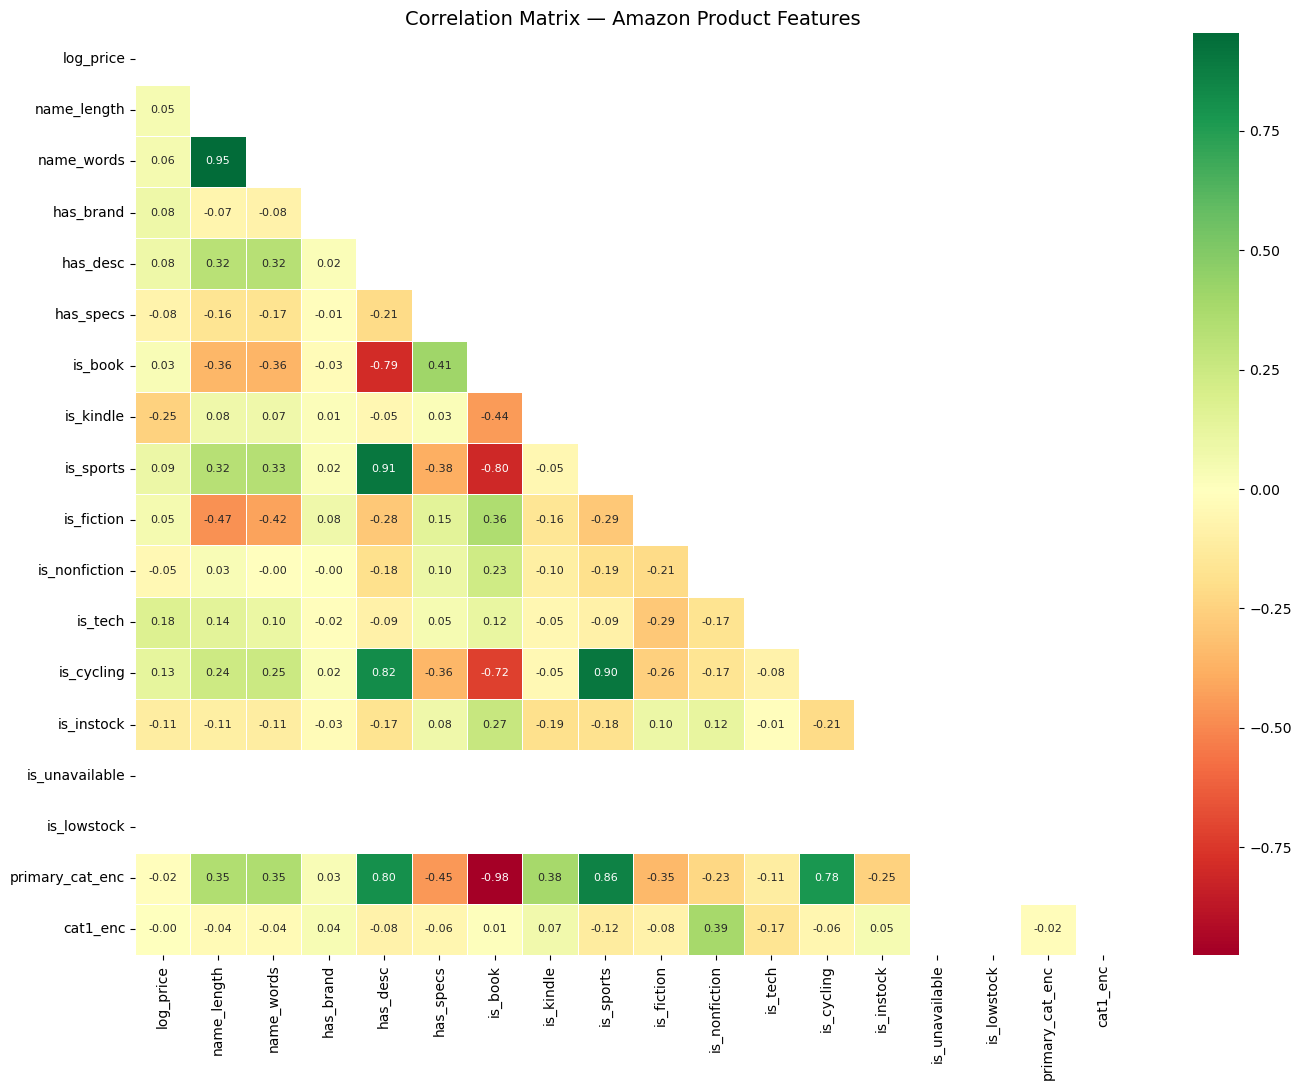

Top correlations with log_price:
is_tech            0.175532
is_cycling         0.125795
is_sports          0.090982
has_brand          0.083593
has_desc           0.080033
name_words         0.055646
is_fiction         0.051064
name_length        0.049355
is_book            0.029688
cat1_enc          -0.002107
primary_cat_enc   -0.018140
is_nonfiction     -0.045158
has_specs         -0.078165
is_instock        -0.111915
is_kindle         -0.245963
is_unavailable          NaN
is_lowstock             NaN


In [23]:
# ============================================================
# 🔗 SECCIÓN 7 — Análisis de Correlación
# ============================================================

# Seleccionar las variables numéricas y categóricas codificadas
# que serán utilizadas para analizar las relaciones entre ellas
corr_cols = [
    'log_price', 'name_length', 'name_words', 'has_brand',
    'has_desc', 'has_specs', 'is_book', 'is_kindle',
    'is_sports', 'is_fiction', 'is_nonfiction', 'is_tech',
    'is_cycling', 'is_instock', 'is_unavailable',
    'is_lowstock', 'primary_cat_enc', 'cat1_enc'
]

# Calcular la matriz de correlación entre las variables seleccionadas
corr = df_priced[corr_cols].corr()

# Crear una máscara para ocultar la mitad superior de la matriz
# y evitar mostrar información duplicada
mask = np.triu(np.ones_like(corr, dtype=bool))

# ============================================================
# Mapa de calor (Heatmap) de correlaciones
# ============================================================

# Crear figura para visualizar las correlaciones
plt.figure(figsize=(14, 11))

# Generar mapa de calor
# Los colores indican la fuerza y dirección de la correlación:
# Verde = correlación positiva
# Rojo = correlación negativa
# Amarillo = correlación cercana a cero
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.4,
    annot_kws={'size': 8}
)

# Configuración del gráfico
plt.title('Correlation Matrix — Amazon Product Features', fontsize=14)

# Ajustar espacios automáticamente
plt.tight_layout()

# Mostrar gráfico
plt.show()

# ============================================================
# Correlaciones con el precio
# ============================================================

# Mostrar las variables más relacionadas con el precio
# (log_price), excluyendo la autocorrelación
print('Top correlations with log_price:')

print(
    corr['log_price']
    .drop('log_price')
    .sort_values(ascending=False)
    .to_string()
)

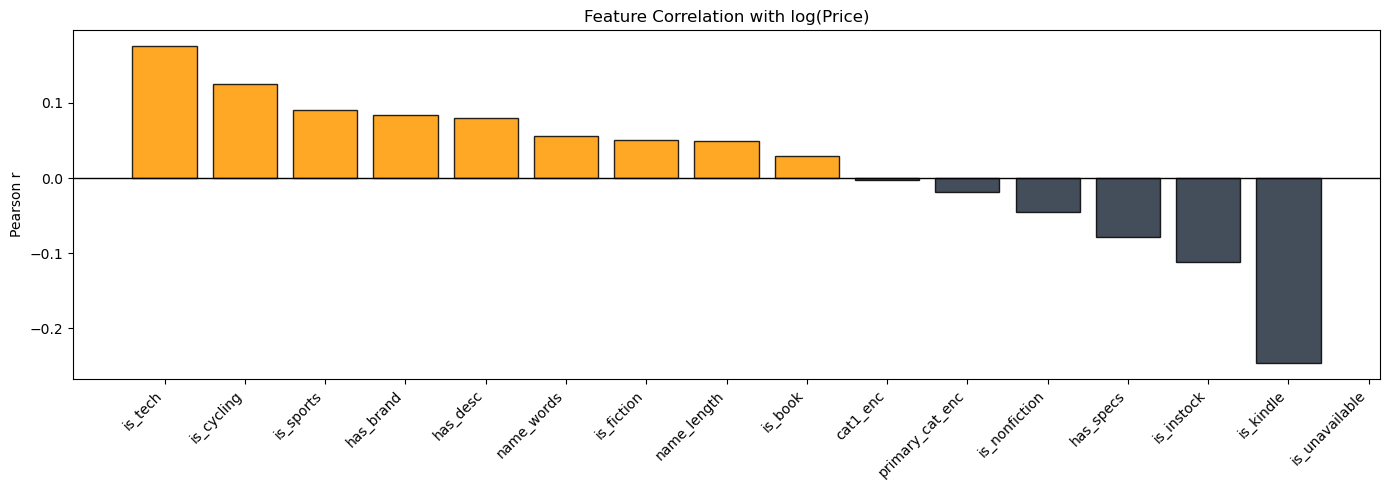

In [24]:
# Se calculan las correlaciones de todas las variables con 'log_price'
# Se eliminan los valores de 'log_price' consigo mismo
# Luego se ordenan de mayor a menor correlación
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

# Se crea una figura para el gráfico con tamaño 14x5 pulgadas
plt.figure(figsize=(14, 5))

# Se definen los colores de las barras:
# Naranja (#FF9900) si la correlación es positiva
# Azul oscuro (#232F3E) si la correlación es negativa
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]

# Se crea un gráfico de barras con:
# - variables en el eje X
# - valores de correlación en el eje Y
# - color personalizado por signo
# - borde negro y transparencia del 85%
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)

# Se agrega una línea horizontal en 0 para distinguir correlaciones positivas y negativas
plt.axhline(0, color='black', lw=1)

# Título del gráfico
plt.title('Feature Correlation with log(Price)')

# Etiqueta del eje Y
plt.ylabel('Pearson r')

# Se rotan las etiquetas del eje X para mejor legibilidad
plt.xticks(rotation=45, ha='right')

# Ajusta automáticamente los márgenes para que no se encimen los elementos
plt.tight_layout()

# Muestra el gráfico final
plt.show()

C:\Users\PC-25\AppData\Local\Temp\ipykernel_8824\99063665.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


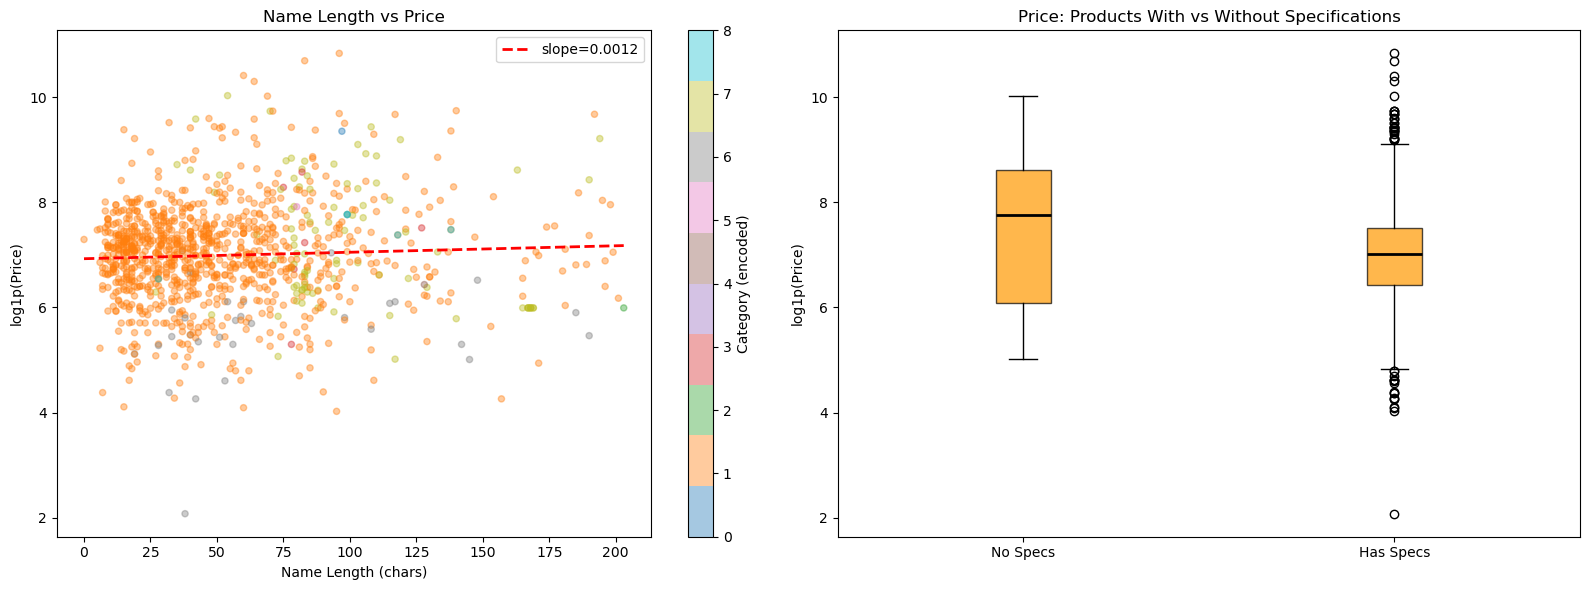

In [25]:
# Se crean 2 subgráficas en una fila (1x2) con tamaño 16x6
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# =========================
# GRÁFICO 1: Scatter plot
# =========================

# Se crea un scatter plot:
# - Eje X: longitud del nombre del producto
# - Eje Y: log del precio
# - Color: categoría codificada (primary_cat_enc)
# - alpha: transparencia (0.4 para ver densidad)
# - s: tamaño de los puntos
sc = axes[0].scatter(
    df_priced['name_length'],
    df_priced['log_price'],
    c=df_priced['primary_cat_enc'],
    cmap='tab10',
    alpha=0.4,
    s=20
)

# Se agrega barra de color para interpretar las categorías
plt.colorbar(sc, ax=axes[0], label='Category (encoded)')

# Se ajusta una línea de regresión lineal (mínimos cuadrados)
# m = pendiente, b = intercepto
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)

# Se generan valores X para dibujar la línea de tendencia
x = np.linspace(0, df_priced['name_length'].max(), 100)

# Se dibuja la línea de tendencia en rojo punteado
axes[0].plot(x, m*x + b, 'r--', lw=2, label=f'slope={m:.4f}')

# Etiquetas del eje X y Y
axes[0].set_xlabel('Name Length (chars)')
axes[0].set_ylabel('log1p(Price)')

# Título del gráfico
axes[0].set_title('Name Length vs Price')

# Se muestra la leyenda (pendiente de la regresión)
axes[0].legend()

# =========================
# GRÁFICO 2: Boxplot
# =========================

# Se comparan dos grupos:
# - Productos sin especificaciones (has_specs == 0)
# - Productos con especificaciones (has_specs == 1)
# Se aplica log1p al precio para normalizarlo

axes[1].boxplot(
    [
        np.log1p(df_priced[df_priced['has_specs'] == 0]['price_clean']),
        np.log1p(df_priced[df_priced['has_specs'] == 1]['price_clean'])
    ],
    labels=['No Specs', 'Has Specs'],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)

# Título del segundo gráfico
axes[1].set_title('Price: Products With vs Without Specifications')

# Etiqueta del eje Y
axes[1].set_ylabel('log1p(Price)')

# Ajusta el layout para evitar solapamientos
plt.tight_layout()

# Muestra ambos gráficos
plt.show()